<h1>Gaia Star Cluster Hertzsprung Russel Diagrams (HRD)</h1>

Here are some useful links 
- [European Space Agency Gaia Mission - Writing Queries Turorial](https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries)
- [Gaia's Hertzsprung-Russel Diagram](https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram)
- [Measuring the Age of a Star Cluster](https://www.e-education.psu.edu/astro801/content/l7_p6.html#:~:text=The%20HR%20diagram%20for%20stage,%2D13%20billion%20years%20old)

**In the examples below we will query open clusters in the Milky way and plot it in a Hertzsprung-Russel Diagram (HRD). We will also attempt to identify the Main Sequence Cutoff points for these star clusters**

*adapted for the Python for Astronomy Course by Chandru Narayan using the material originally develped by Dr. Priya Hasan and the Gaia utilities*

# Steps to create Hertzsprung-Russel Diagram

- Step 1:  Install the required libraries for astronomy data analysis, querying, and plotting.
- Step 2:  Import the necessary modules from the installed libraries.
- Step 3:  Query the Gaia archive for data within a specified radius around a given cluster.
- Step 4a: Create a Dataframe and Cleanup data as needed.
- Step 4b: Calculate absolute magnitudes and colors from the Gaia data.
- Step 5:  Generate HR diagrams, plotting absolute magnitude against color.
- Repeat Steps 3-5 above for another Star Cluster

## Step 1: Install necessary libraries as necessary

In [1]:
# pip install astropy astroquery matplotlib google

## Step 2: Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia
import astropy.coordinates as coord
import pandas as pd

## Step 3: Query Gaia data

### First perform a Google Search about your target

In [3]:
### Setup your target here
target_id = 'M67'

In [4]:
def googlesearchurl(tname):
    try:
        from googlesearch import search
    except ImportError:
        print("No module named 'google' found")
    #
    # to search
    query = f'{target_id} Wikipedia Astronomy'
    
    #for j in search(query, tld="co.us", num=10, stop=10, pause=2):
    for url in search(query, num_results=10, lang="en", unique=True):
        print(url)
#
# example
#
googlesearchurl(target_id)

https://en.wikipedia.org/wiki/Messier_67
https://en.wikipedia.org/wiki/Messier_object
https://commons.wikimedia.org/wiki/File:M67,_NGC_2682_(noao-m67pump).jpg
https://science.nasa.gov/mission/hubble/science/explore-the-night-sky/hubble-messier-catalog/messier-67/
https://en.wikipedia.org/wiki/Main_sequence
https://en.wikibooks.org/wiki/Messier_Index/M67
https://www.google.com/search?num=12
https://en.wikipedia.org/wiki/Solar_analog
https://www.wikiwand.com/en/articles/Messier_67
https://www.facebook.com/groups/237147005479572/posts/573161928544743/


In [5]:
%%html
<div style="text-align:center;">
<iframe src="https://gea.esac.esa.int/archive/" width="900" height="540"></iframe>
</div>

### Perform your Query

In [6]:
# Parameters for API Query & HRD (20 minutes radius around Cluster center) - Change for each query!
target = target_id # target to query
object_radius = 1/2 * u.deg # in deg
coordinate = coord.SkyCoord.from_name(target)
print(coordinate)

# Define cluster coordinates and radius for Cone search
radius = object_radius
ra = coordinate.ra
dec = coordinate.dec


<SkyCoord (ICRS): (ra, dec) in deg
    (132.848, 11.815)>


In [7]:
# Query strings for Gaia
# Query 1
query1 = f"""
    SELECT ra, dec, parallax, 1000/parallax as dist, phot_g_mean_mag, bp_rp
    FROM gaiaedr3.gaia_source 
    WHERE parallax > 0 
    AND 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra.value}, {dec.value}, {radius.value})
        )
"""
# Query 2
query2 = f"""
    SELECT ra, dec, parallax, 1000/parallax as dist, phot_g_mean_mag, bp_rp
    FROM gaiaedr3.gaia_source 
    WHERE parallax > 0 
    AND bp_rp > -0.75
    AND bp_rp < 6
    AND visibility_periods_used > 8
    AND phot_g_mean_flux_over_error > 50
    AND phot_bp_mean_flux_over_error > 20
    AND phot_rp_mean_flux_over_error > 20
    and phot_bp_rp_excess_factor <
    1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)
    and phot_bp_rp_excess_factor >
    1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)
    and astrometric_chi2_al/(astrometric_n_good_obs_al-5)<
    1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))
    AND 1=CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra.value}, {dec.value}, {radius.value})
        )
""" 

In [8]:
# create and launch async query
job = Gaia.launch_job_async(query2)
gaia_data = job.get_results()
#print(gaia_data)

INFO: Query finished. [astroquery.utils.tap.core]


## Step 4a: Create a Data Frame & Cleanup Gaia Query Results data

In [9]:
# Create a DataFrame and Cleanup specific to your target:
allstars = gaia_data.to_pandas()
print("allstars\n",allstars)
# filter allstars
allstars.dropna(inplace=True)  # Drop NaN - "not a number"
print("allstars_cleaned\n",allstars)
# filter for dist between 800 & 900 pc (allstars_filtered) by creating a mask
#mask = (allstars.dist >= 800) & (allstars.dist <= 900) & (allstars.bp_rp >= 0.7) & (allstars.bp_rp <= 0.8)
mask = (allstars.dist >= 800) & (allstars.dist <= 900)
allstars = allstars[mask]
print("allstars_masked\n",allstars)

allstars
               ra        dec  parallax          dist  phot_g_mean_mag     bp_rp
0     133.056987  11.376465  0.628439   1591.245248        15.445424  0.833028
1     133.041451  11.379611  0.067331  14852.067587        18.142157  0.800323
2     133.064952  11.383630  1.817527    550.198051        14.547466  1.152339
3     133.078791  11.397105  1.046245    955.798795        14.919369  0.921084
4     133.078004  11.399285  2.063607    484.588464        15.843439  1.583776
...          ...        ...       ...           ...              ...       ...
2783  132.373163  11.818868  1.739473    574.886787        18.533737  2.453894
2784  132.372886  11.827185  0.531927   1879.958669        16.709026  0.865046
2785  132.370036  11.842801  0.501733   1993.093076        15.592101  0.751378
2786  132.341900  11.870370  0.757106   1320.819583        15.535884  0.871829
2787  132.349702  11.871316  0.413303   2419.532360        16.959467  1.077908

[2788 rows x 6 columns]
allstars_cleaned


## Step 4b: Calculate absolute magnitude and add to DataFrame

### Review Formulas (we drived these in the Star MAgnitudes Module!)
#### The quantity $\boxed{m_{app} - m_{abs}} $ OR $ \boxed {m - M} $ is known as the distance modulus
#### Note that this quantity appears in the equations below to calculate magnitudes and distance
### 1. How to calculate Magnitudes when distance (in pc) is known
#### $$ \boxed{m - M =  5 \times log_{10}(distance) - 5} $$
### 2. How to calculate Magnitudes when parallax (in arc-sec) is known
#### $$ \boxed{m - M =  5 \times log_{10}(1/parallax) - 5} $$
### 3. How to calculate Magnitudes for Gaia calculations when parallax (in milli-arc-sec or 'mas') is known
##### $$ \boxed{m -M = - 5 \times log_{10}(parallax) + 10} $$ OR $$ \boxed{M = m + 5 \times log_{10}(parallax) - 10} $$
#### 4. How to calculate Distance (in pc) when apparent and absolute magnitudes are known
##### $$ \boxed{distance = 10^{\frac{m - M+5}{5}}} $$

In [10]:
# Calculate absolute magnitude with parallax in mas
# Make sure parallax > 0 by creating another filter

distance_modulus = -5 * np.log10(allstars['parallax']) + 10
abs_mag = allstars['phot_g_mean_mag'] - distance_modulus
bp_rp = allstars['bp_rp']

## Step 5: Plot HR diagram

### Simple Plot of HRD

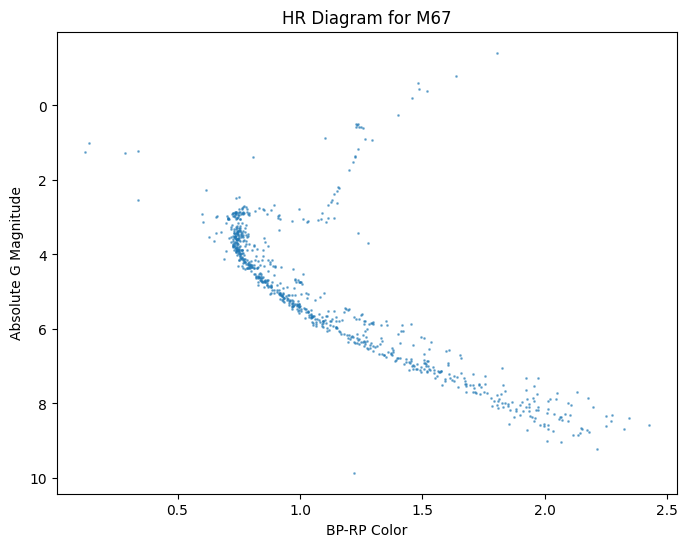

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for {target}")
plt.show()

### Simple Plot of HRD with the sun

In [12]:
# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * np.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

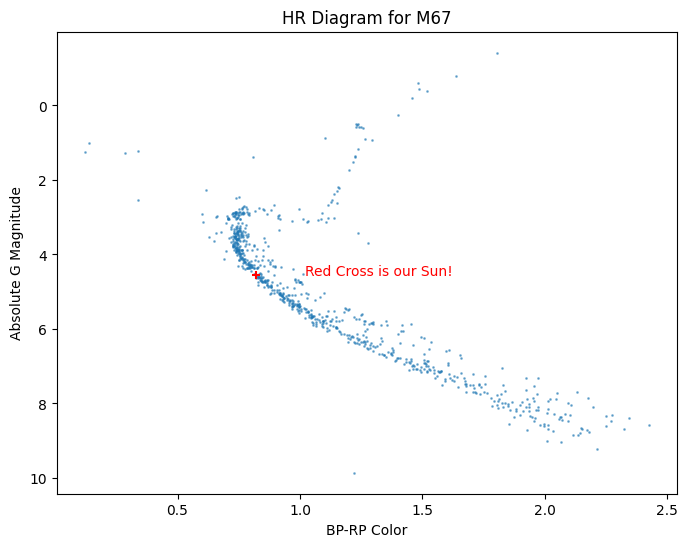

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(bp_rp, abs_mag, s=1, alpha=0.5) # plot stars
plt.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red") # mark sun
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color")
plt.ylabel("Absolute G Magnitude")
plt.title(f"HR Diagram for {target}")
plt.show()

### Decorated Binned Plot of HRD

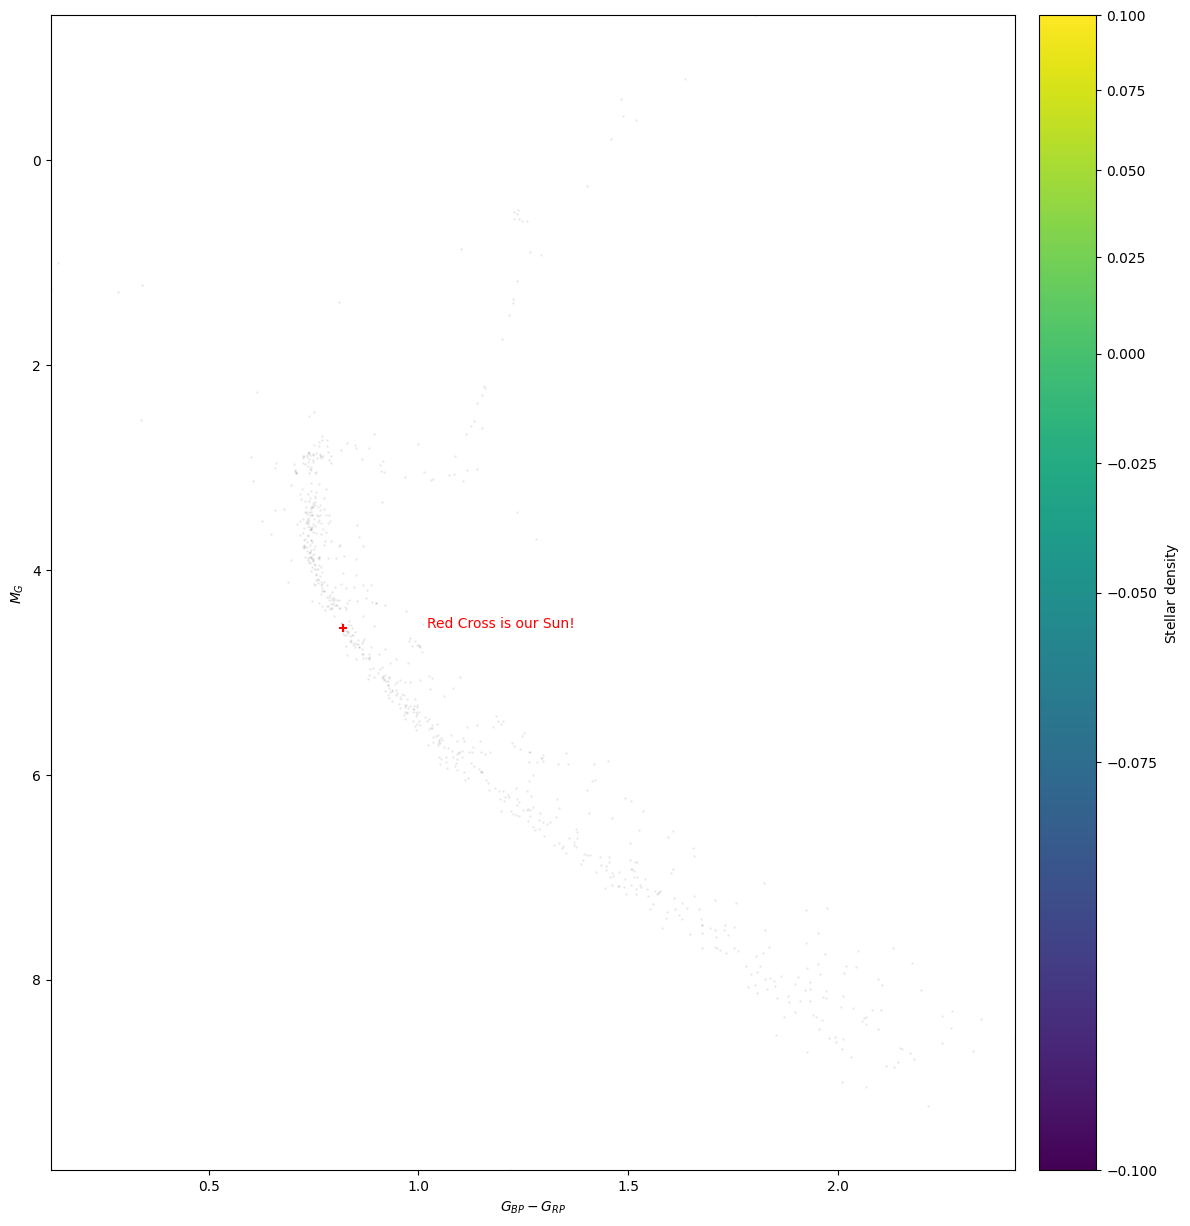

In [14]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))

# only show 2D-histogram for bins with more than 10 stars in them
# plot the Sun
ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun

#h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
h = ax.hist2d(bp_rp,abs_mag, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp,abs_mag, alpha=0.05, s=1, color='k', zorder=0)

# mark the Sun
plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")

ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"m67.png", dpi=140)
plt.show()

# Repeat Steps 3 to 5 for another Star Cluster